# NB0: Data Preparation -- QC & Phenotype Classification

**FunPan Aspergillus Pangenome Project**

Pipeline steps:

1. Quality control: BUSCO completeness, contig count and N50 filters
2. Species verification: fastANI against each species reference, plus a section *Nigri* re-check for low-ANI *A. niger*
3. Two-tier classification: Provenance and Phenotype labels, with NCBI BioProject and WGS title enrichment
4. Per-species phenotype sheets and binary contrast files

All outputs are saved to `NB0_Results/`.

Analysis functions live in `funpan_utils.py` and `funpan_classify.py`. Sections 2
to 6 each open with a bootstrap cell that sets the paths, imports those modules and
reloads that section's inputs from `NB0_Results/`, so any section can be run on its
own from a fresh kernel. Edit the path block at the top of a bootstrap cell to point
the notebook at your own directories.

---
## Section 1: Configuration

- Imports, project constants and the `NB0_Results/` output directory
- Cached enrichment artefacts are reused so the NCBI API is not re-queried

In [1]:
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB0_Results')

sys.path.insert(0, ANALYSIS_DIR)
from funpan_utils import *
import funpan_classify as classify
import matplotlib.pyplot as plt

GENUS = 'Aspergillus'
SPECIES_ROOT_MAP = {sp: os.path.join(SPECIES_DIR, GENUS, sp) for sp in SPECIES_LIST}

os.makedirs(RESULTS_BASE, exist_ok=True)
ENRICHED_CACHE = os.path.join(RESULTS_BASE, 'qc_passed_metadata_enriched.csv')

print('Configuration complete.')
print(f'Species: {SPECIES_LIST}')
print(f'Results will be saved to: {RESULTS_BASE}')

Configuration complete.
Species: ['fumigatus', 'flavus', 'niger', 'oryzae']
Results will be saved to: /datadrive/Analysis/NB0_Results


---
## Section 2: Metadata & Quality Control

- Load NCBI genome metadata, apply QC filters, select a reference per species
- Verify species identity by ANI and drop misidentified assemblies
- Re-test low-ANI *A. niger* genomes against the sister section *Nigri* species

In [2]:
# Standalone bootstrap: run this cell to use Section 2 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB0_Results')

sys.path.insert(0, ANALYSIS_DIR)
from funpan_utils import *
import funpan_classify as classify
import matplotlib.pyplot as plt

GENUS = 'Aspergillus'
SPECIES_ROOT_MAP = {sp: os.path.join(SPECIES_DIR, GENUS, sp) for sp in SPECIES_LIST}


### 2.1 Metadata & QC filters

- `load_and_prepare_metadata()`: loads NCBI metadata, flags BUSCO / contig / N50 failures, selects the reference genome and proteome per species
- `apply_ani_exclusions()`: drops assemblies that fail ANI species verification

In [3]:
df_all, filtered_accs, proteome_accs, references = load_and_prepare_metadata(
    genus=GENUS, species_list=SPECIES_LIST
)

Loading metadata for all downloaded genomes...
Total genomes downloaded: 929
  fumigatus: 89 passed filtering
  flavus: 71 passed filtering
  niger: 19 passed filtering
  oryzae: 33 passed filtering

Proteomes available (filtered_protein):
  fumigatus: 30 proteomes
  flavus: 4 proteomes
  niger: 4 proteomes
  oryzae: 3 proteomes

Filtering summary: 212 passed, 717 filtered out
Identifying reference genomes (parsnp) and proteomes (funannotate)...
  fumigatus: Ref Genome = GCF_000002655.1 (RefSeq)
  fumigatus: Ref Proteome = GCF_000002655.1 (RefSeq) [SAME]
  flavus: Ref Genome = GCF_014117465.1 (RefSeq)
  flavus: Ref Proteome = GCF_014117465.1 (RefSeq) [SAME]
  niger: Ref Genome = GCF_000002855.4 (RefSeq)
  niger: Ref Proteome = GCF_000002855.4 (RefSeq) [SAME]
  oryzae: Ref Genome = GCF_000184455.2 (RefSeq)
  oryzae: Ref Proteome = GCF_000184455.2 (RefSeq) [SAME]

Reference summary:
  Ref genomes: 4
  Ref proteomes: 4


In [4]:
# Excluded accessions are defined in funpan_utils.NB0_ANI_EXCLUDED
ANI_EXCLUDED = NB0_ANI_EXCLUDED
print('Excluding:', {sp: sorted(a) for sp, a in ANI_EXCLUDED.items()})
all_passed_accs = apply_ani_exclusions(df_all, filtered_accs, ANI_EXCLUDED)

Excluding: {'flavus': ['GCA_023653635.1'], 'fumigatus': ['GCA_049901915.1']}
  ANI exclusion: removed 1 from flavus
  ANI exclusion: removed 1 from fumigatus
  After ANI exclusion: 210 passed
  fumigatus: 88 passed QC
  flavus: 70 passed QC
  niger: 19 passed QC
  oryzae: 33 passed QC

Total QC-passed assemblies: 210


In [5]:
print('References per species:')
for sp, ref in references.items():
    print(f'  {sp}: genome={ref.get("ref_genome")}, proteome={ref.get("ref_proteome")}')

References per species:
  fumigatus: genome=GCF_000002655.1, proteome=GCF_000002655.1
  flavus: genome=GCF_014117465.1, proteome=GCF_014117465.1
  niger: genome=GCF_000002855.4, proteome=GCF_000002855.4
  oryzae: genome=GCF_000184455.2, proteome=GCF_000184455.2


### 2.2 QC & ANI diagnostic plots

- Per-species QC metric distributions, with the reference and any ANI-excluded genomes marked
- ANI of every assembly against its species reference, relative to the 95% species threshold

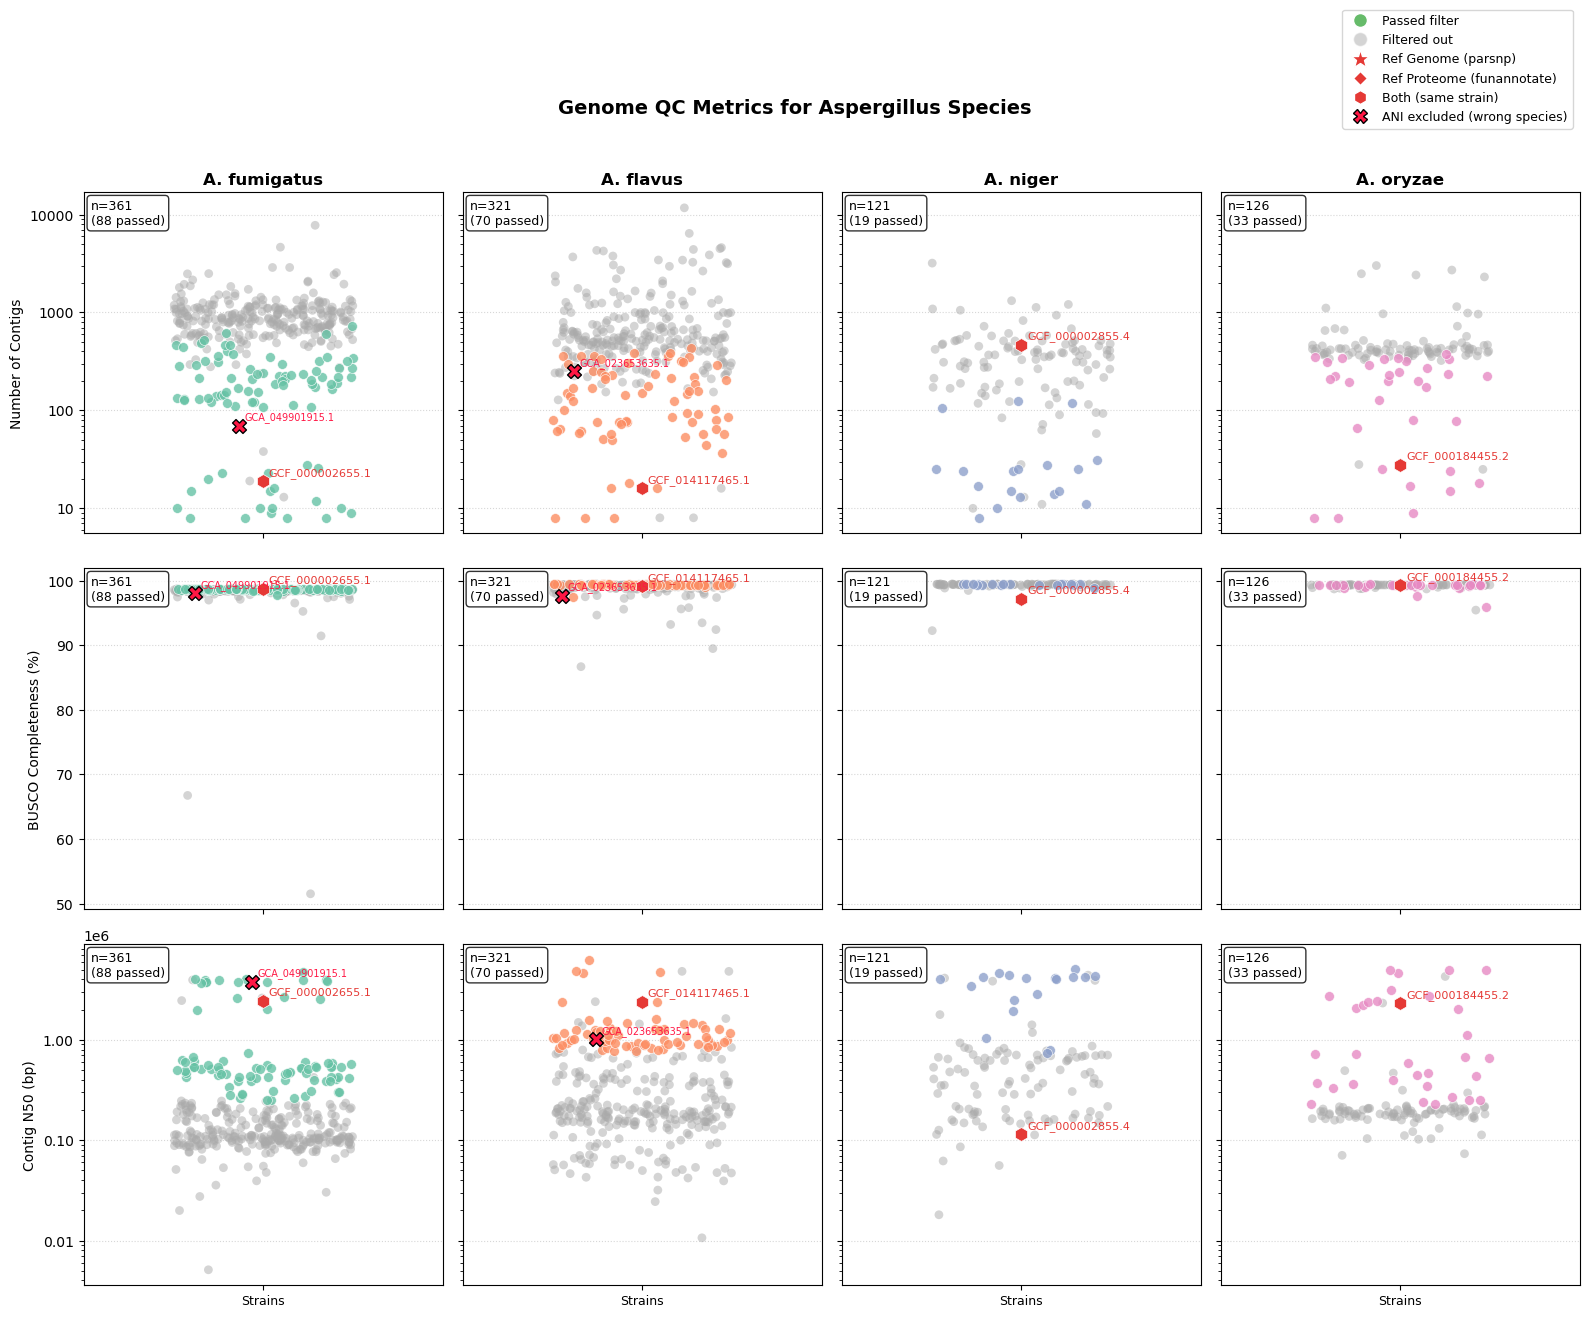

Saved QC metrics plot to /datadrive/Analysis/NB0_Results/qc_metrics.png


In [6]:
plot_qc_metrics_per_species(df_all, SPECIES_LIST, references, ani_excluded=ANI_EXCLUDED)
plt.savefig(os.path.join(RESULTS_BASE, 'qc_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved QC metrics plot to {RESULTS_BASE}/qc_metrics.png')

ANI SPECIES VERIFICATION
  fumigatus: 89 genomes, ANI range: 99.19 - 100.00%, 0 below 95%
  flavus: 71 genomes, ANI range: 94.08 - 100.00%, 1 below 95%
  niger: 19 genomes, ANI range: 97.50 - 100.00%, 0 below 95%
  oryzae: 33 genomes, ANI range: 99.21 - 100.00%, 0 below 95%

Threshold: 95% ANI -- samples below are likely different species


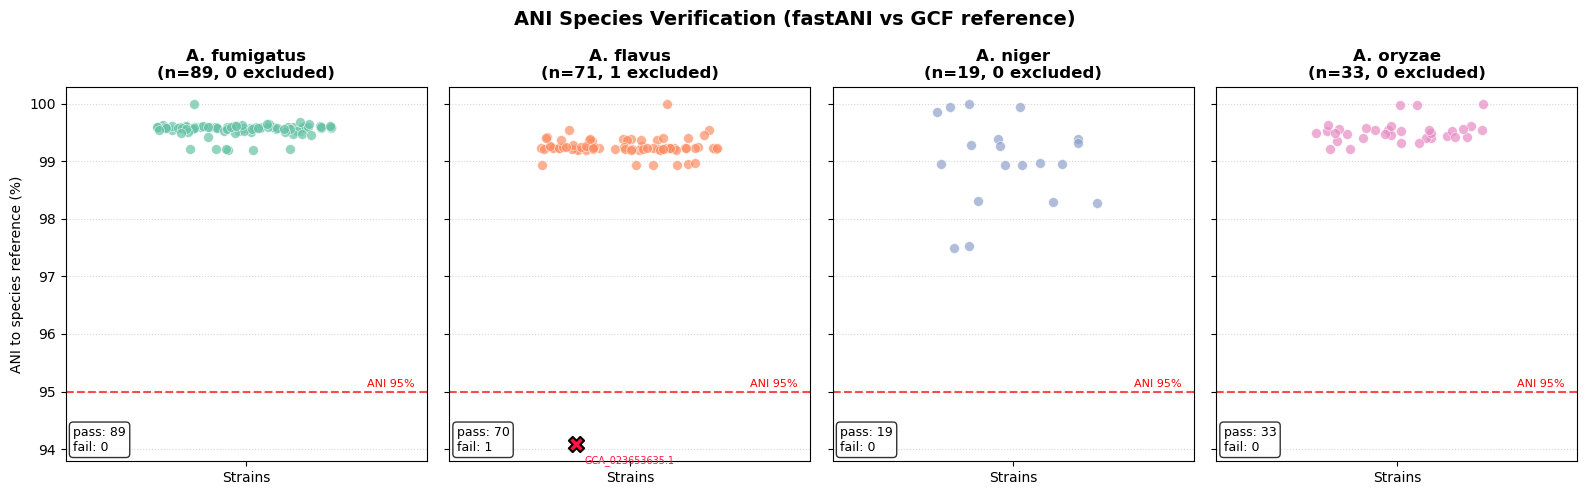

In [7]:
print('=' * 80)
print('ANI SPECIES VERIFICATION')
print('=' * 80)
ani_results_all = load_ani_results(SPECIES_LIST, RESULTS_BASE)
plot_ani_verification(ani_results_all, SPECIES_LIST, RESULTS_BASE)

### 2.3 Section *Nigri* identity check

- `check_section_nigri()` re-tests *A. niger* genomes below the 95% ANI threshold against the *A. tubingensis* and *A. welwitschiae* references
- Outputs: per-comparison tables in `NB0_Results/nigri_check/`, summary in `NB0_Results/niger_section_nigri_reassignment.csv`
- Requires `fastANI`, `wget` and internet access; the first run downloads the two references

> Reference accessions and threshold: `funpan_utils.NIGRI_REFS` and
> `funpan_utils.ANI_SPECIES_THRESHOLD`.

In [8]:
nigri_df = check_section_nigri(RESULTS_BASE, species_root=SPECIES_ROOT_MAP['niger'])
if not nigri_df.empty:
    display(nigri_df)

SECTION NIGRI CHECK -- low-ANI A. niger genomes
A. niger reference: GCF_000002855.4_ASM285v2_genomic.fna
Filtered genomes:   19
Below 95.0% ANI to A. niger: 0
All filtered A. niger genomes pass the species threshold -- nothing to reassign.


### 2.4 QC summary tables

- Filtering and reference summary per species
- QC metric statistics across the genomes that passed

In [9]:
summary_df, qc_stats_df = build_qc_summary_tables(df_all, SPECIES_LIST, references)
print('Genome QC Filtering & Reference Summary:')
print('=' * 120)
display(summary_df)
print('\nQC Metrics Summary (passed genomes only):')
display(qc_stats_df)

Genome QC Filtering & Reference Summary:


,Species,Downloaded,Passed,Filtered,Pass %,Ref Genome,G Type,Ref Proteome,P Type,Same?
0,A. fumigatus,361,88,273,24.4,GCF_000002655.1,RefSeq,GCF_000002655.1,RefSeq,Yes
1,A. flavus,321,70,251,21.8,GCF_014117465.1,RefSeq,GCF_014117465.1,RefSeq,Yes
2,A. niger,121,19,102,15.7,GCF_000002855.4,RefSeq,GCF_000002855.4,RefSeq,Yes
3,A. oryzae,126,33,93,26.2,GCF_000184455.2,RefSeq,GCF_000184455.2,RefSeq,Yes



QC Metrics Summary (passed genomes only):


,Species,Median Contigs,Median BUSCO,Median N50,Min BUSCO,Max Contigs
0,A. fumigatus,186,98.7%,0.52 Mb,97.8%,730
1,A. flavus,126,99.4%,1.04 Mb,97.5%,435
2,A. niger,24,99.4%,4.07 Mb,97.2%,469
3,A. oryzae,200,99.3%,0.67 Mb,95.9%,375


In [10]:
n_total = len(df_all)
n_passed = sum(len(v) for v in filtered_accs.values())
n_excluded = sum(len(v) for v in ANI_EXCLUDED.values()) if 'ANI_EXCLUDED' in dir() else 0
print(f'QC Summary')
print(f'==========')
print(f'{n_total} genomes downloaded across {len(SPECIES_LIST)} Aspergillus species.')
print(f'{n_passed} passed quality filters (BUSCO completeness, contig count, N50).')
if n_excluded > 0:
    print(f'{n_excluded} excluded by ANI species verification (fastANI < 95%).')
for sp in SPECIES_LIST:
    n_sp = len(filtered_accs.get(sp, []))
    n_ex = len(ANI_EXCLUDED.get(sp, set())) if 'ANI_EXCLUDED' in dir() else 0
    print(f'  A. {sp}: {n_sp} passed QC' + (f', {n_ex} ANI-excluded' if n_ex else ''))

QC Summary
929 genomes downloaded across 4 Aspergillus species.
210 passed quality filters (BUSCO completeness, contig count, N50).
2 excluded by ANI species verification (fastANI < 95%).
  A. fumigatus: 88 passed QC, 1 ANI-excluded
  A. flavus: 70 passed QC, 1 ANI-excluded
  A. niger: 19 passed QC
  A. oryzae: 33 passed QC


---
## Section 3: Phenotype Classification

- Two-tier classification assigning each genome a Provenance and a Phenotype label
- NCBI BioProject and WGS titles supply the text scored by the rules engine

In [11]:
# Standalone bootstrap: run this cell to use Section 3 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB0_Results')

sys.path.insert(0, ANALYSIS_DIR)
from funpan_utils import *
import funpan_classify as classify
import matplotlib.pyplot as plt

GENUS = 'Aspergillus'
SPECIES_ROOT_MAP = {sp: os.path.join(SPECIES_DIR, GENUS, sp) for sp in SPECIES_LIST}

ENRICHED_CACHE = os.path.join(RESULTS_BASE, 'qc_passed_metadata_enriched.csv')

# No cached table for df_all, so Section 2's QC state is re-derived (a few seconds)
df_all, filtered_accs, references, all_passed_accs = load_qc_state(
    genus=GENUS, species_list=SPECIES_LIST
)

Loading metadata for all downloaded genomes...
Total genomes downloaded: 929
  fumigatus: 89 passed filtering
  flavus: 71 passed filtering
  niger: 19 passed filtering
  oryzae: 33 passed filtering

Proteomes available (filtered_protein):
  fumigatus: 30 proteomes
  flavus: 4 proteomes
  niger: 4 proteomes
  oryzae: 3 proteomes

Filtering summary: 212 passed, 717 filtered out
Identifying reference genomes (parsnp) and proteomes (funannotate)...
  fumigatus: Ref Genome = GCF_000002655.1 (RefSeq)
  fumigatus: Ref Proteome = GCF_000002655.1 (RefSeq) [SAME]
  flavus: Ref Genome = GCF_014117465.1 (RefSeq)
  flavus: Ref Proteome = GCF_014117465.1 (RefSeq) [SAME]
  niger: Ref Genome = GCF_000002855.4 (RefSeq)
  niger: Ref Proteome = GCF_000002855.4 (RefSeq) [SAME]
  oryzae: Ref Genome = GCF_000184455.2 (RefSeq)
  oryzae: Ref Proteome = GCF_000184455.2 (RefSeq) [SAME]

Reference summary:
  Ref genomes: 4
  Ref proteomes: 4
  ANI exclusion: removed 1 from flavus
  ANI exclusion: removed 1 from

### 3.1 NCBI metadata enrichment

- `load_or_build_enriched_metadata()`: reads the cached enriched table if present, otherwise queries NCBI and writes the cache

In [12]:
df_meta = load_or_build_enriched_metadata(all_passed_accs, ENRICHED_CACHE, RESULTS_BASE)

Loading pre-enriched metadata from /datadrive/Analysis/NB0_Results/qc_passed_metadata_enriched.csv
  Loaded 210 assemblies

Saved enriched metadata to /datadrive/Analysis/NB0_Results/qc_passed_metadata_enriched.csv

Species distribution:
Species
A. fumigatus    88
A. flavus       70
A. oryzae       33
A. niger        19
Name: count, dtype: int64

BioProject Description: 210/210 non-empty

WGS Reference Title: 196/210 non-empty


### 3.2 Classification & outputs

- `classify.classify_dataframe()`: applies the two-tier rules engine
- `save_classified_outputs()`: writes the full table and the analysis subset (known phenotypes only)

In [13]:
print('Running TWO-TIER classification on QC-passed assemblies...')
df_classified = classify.classify_dataframe(df_meta, debug=False)
print('Classification complete!')
classify.summarize_classification(df_classified)

Running TWO-TIER classification on QC-passed assemblies...
Classification complete!

TWO-TIER ISOLATION SOURCE CLASSIFICATION SUMMARY

Total samples: 210

----------------------------------------------------------------------
A) PROVENANCE (where physically isolated from)
----------------------------------------------------------------------
  Clinical: 122 (58.1%)
  Environmental: 44 (21.0%)
  Industrial-origin: 26 (12.4%)
  Unknown: 9 (4.3%)
  Culture-derived: 9 (4.3%)

  Confidence by provenance:
  ProvenanceConfidence  high  low  medium
  Provenance                             
  Clinical               104    0      18
  Culture-derived          2    3       4
  Environmental            0   15      29
  Industrial-origin       13    0      13
  Unknown                  0    9       0

----------------------------------------------------------------------
B) PHENOTYPE (biological association - for pan-GWAS)
----------------------------------------------------------------------
  Hum

,count
Phenotype,
Human-pathogenic,81
Environmental,59
Industrial-trait,46
Plant-pathogenic,19
Unknown,4
Animal-pathogenic,1


In [14]:
df_analysis = save_classified_outputs(df_classified, RESULTS_BASE)

Saved FULL classified data (including Unknown) to:
  /datadrive/Analysis/NB0_Results/qc_passed_classified_all.csv

Analysis dataset (excluding 4 Unknown + 0 Lab phenotypes):
Phenotype
Human-pathogenic     81
Environmental        59
Industrial-trait     46
Plant-pathogenic     19
Animal-pathogenic     1

Saved analysis data (excluding Unknown/Lab) to:
  /datadrive/Analysis/NB0_Results/qc_passed_classified_known.csv

Saved pan-GWAS phenotype data to:
  /datadrive/Analysis/NB0_Results/phenotype_classified_for_gwas.csv

Available dataframes:
  df_classified: 210 assemblies (ALL, including Unknown/Lab)
  df_analysis:   206 assemblies (for pan-GWAS, no Unknown/Lab)


In [15]:
print('Classification Summary')
print('=====================')
print(f'{len(df_classified)} genomes classified with two-tier system.')
print(f'{len(df_analysis)} genomes with known phenotype (excl. Unknown/Lab) available for pan-GWAS.')
print()
print('Phenotype distribution:')
for pheno, count in df_analysis['Phenotype'].value_counts().items():
    pct = 100 * count / len(df_analysis)
    print(f'  {pheno}: {count} ({pct:.1f}%)')
print()
print('Provenance distribution:')
for prov, count in df_classified['Provenance'].value_counts().items():
    pct = 100 * count / len(df_classified)
    print(f'  {prov}: {count} ({pct:.1f}%)')

Classification Summary
210 genomes classified with two-tier system.
206 genomes with known phenotype (excl. Unknown/Lab) available for pan-GWAS.

Phenotype distribution:
  Human-pathogenic: 81 (39.3%)
  Environmental: 59 (28.6%)
  Industrial-trait: 46 (22.3%)
  Plant-pathogenic: 19 (9.2%)
  Animal-pathogenic: 1 (0.5%)

Provenance distribution:
  Clinical: 122 (58.1%)
  Environmental: 44 (21.0%)
  Industrial-origin: 26 (12.4%)
  Unknown: 9 (4.3%)
  Culture-derived: 9 (4.3%)


---
## Section 4: Visualization

- Phenotype composition across the analysis set
- Global geographic distribution of the strains, by species

In [16]:
# Standalone bootstrap: run this cell to use Section 4 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB0_Results')

sys.path.insert(0, ANALYSIS_DIR)
from funpan_utils import *
import funpan_classify as classify
import matplotlib.pyplot as plt

GENUS = 'Aspergillus'
SPECIES_ROOT_MAP = {sp: os.path.join(SPECIES_DIR, GENUS, sp) for sp in SPECIES_LIST}

df_analysis = load_analysis_set(RESULTS_BASE)

### 4.1 Phenotype distribution

Saved as two separate figures: a pie chart of overall composition and a bar chart broken
down by species.

Saved to /datadrive/Analysis/NB0_Results/phenotype_distribution_pie.png
Saved to /datadrive/Analysis/NB0_Results/phenotype_distribution_bar.png


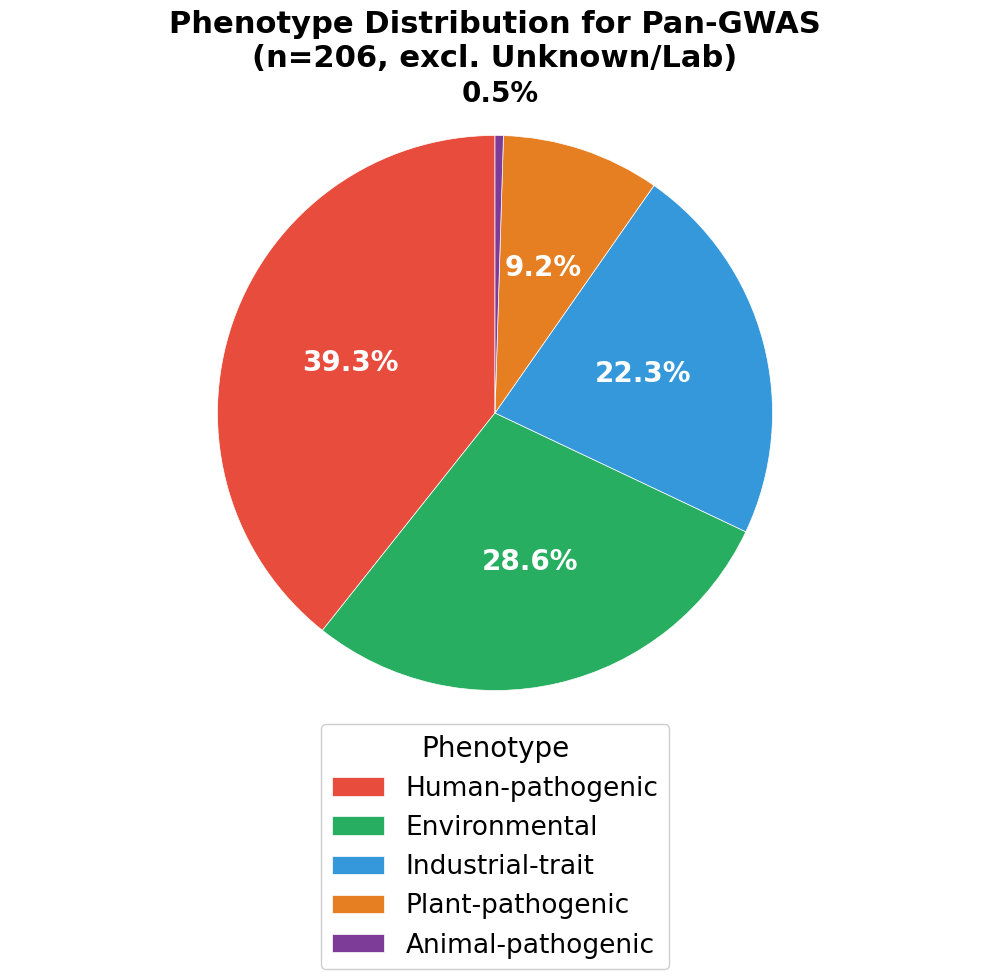

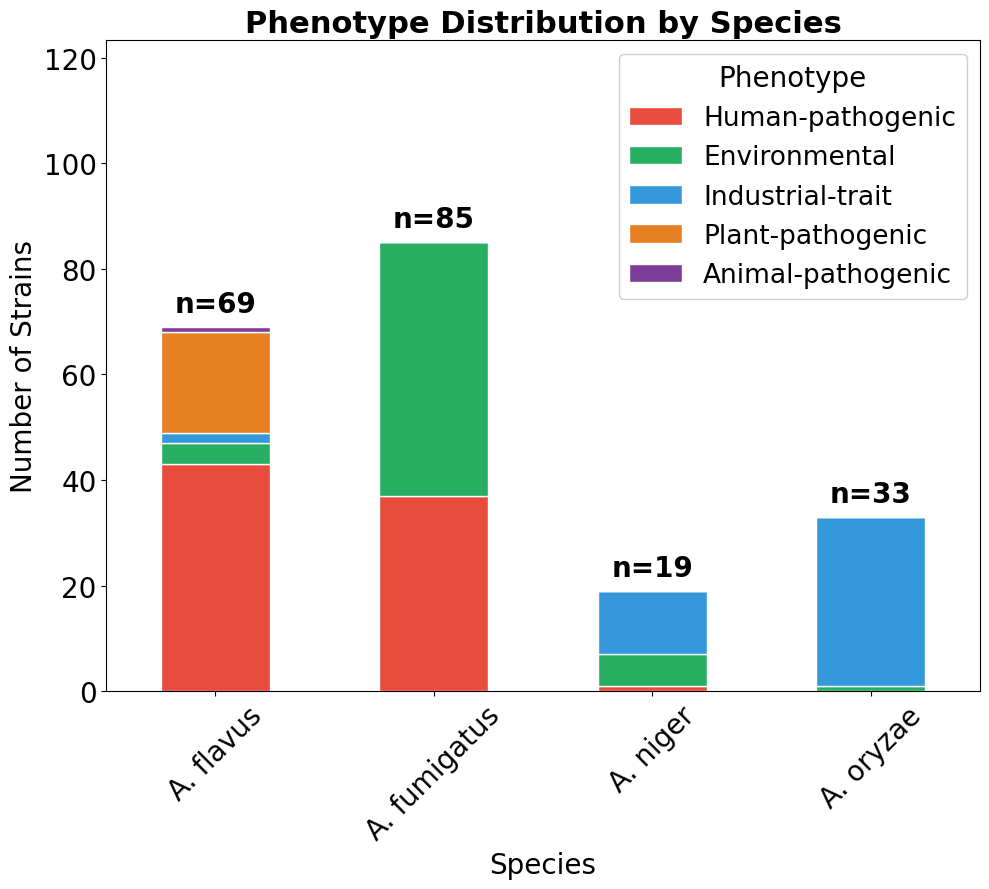

In [17]:
# --- Tweakable parameters ---
FIGURE_FONTSIZE = 20         # base font size (title +2, legend labels -1)
FIGURE_DPI      = 800        # PNG resolution
PIE_FIGSIZE     = (10, 11)   # inches
BAR_FIGSIZE     = (10, 9)    # inches
PIE_LEGEND_NCOL = 1          # 1 = tall single column, 2-3 = wider/shorter
BAR_YLIM_FACTOR = 1.45       # bar y headroom; raise if the legend overlaps a bar

import importlib, funpan_utils
importlib.reload(funpan_utils)
from funpan_utils import plot_phenotype_distribution

fig_pie, fig_bar = plot_phenotype_distribution(
    df_analysis, RESULTS_BASE,
    fontsize=FIGURE_FONTSIZE,
    dpi=FIGURE_DPI,
    pie_figsize=PIE_FIGSIZE,
    bar_figsize=BAR_FIGSIZE,
    pie_legend_ncol=PIE_LEGEND_NCOL,
    bar_ylim_factor=BAR_YLIM_FACTOR,
)

### 4.2 Global strain distribution

World map of strain isolation sites, with marginal density panels along the top
(longitude) and right (latitude) edges. Plot parameters are set in the cell below.

Extracting coordinates for strain locations...
Loaded manual coordinates: 2 by location, 5 by strain

Coordinates found for 186/206 samples (90.3%)
  From Lat/Lon column: 86
  From Manual additions: 10
  From Geo Location (geocoded): 0
  From Geo Location (cached): 90

Map with marginal histograms saved to: /datadrive/Analysis/NB0_Results/strain_world_map_marginals.png


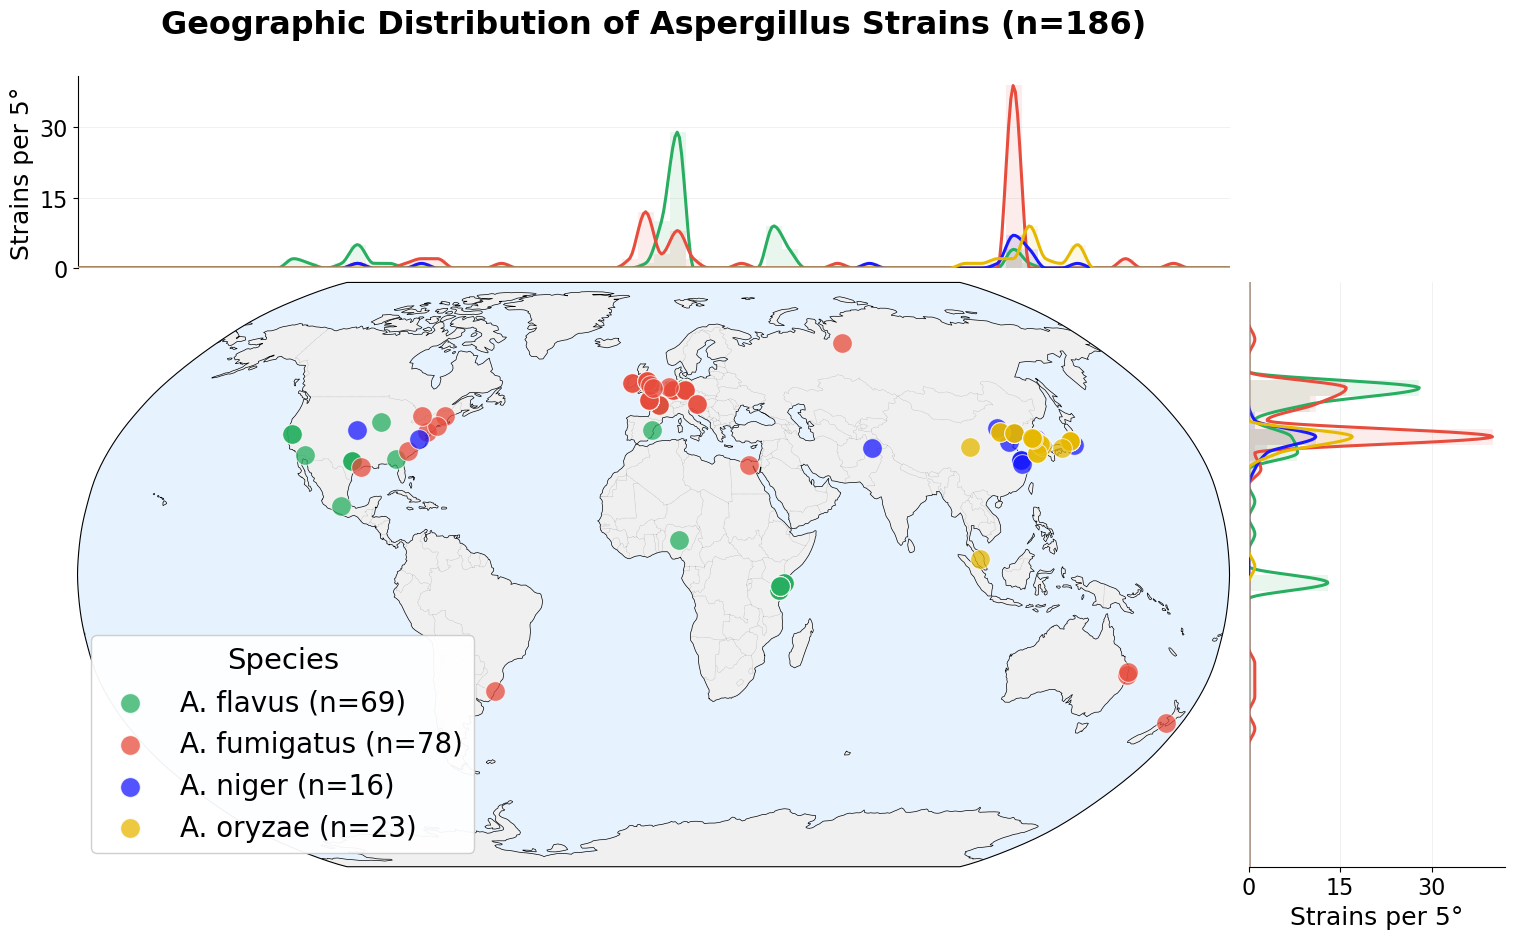

In [18]:
# --- Tweakable parameters ---
FIGURE_FONTSIZE = 20          # base font size (title +3, legend title +1)
FIGURE_DPI      = 800         # PNG resolution
FIGURE_SIZE     = (16, 12)    # inches
MARKER_SIZE     = 200         # scatter marker area (points^2)
N_LON_BINS      = 72          # bins: used by 'hist+kde'/'overlap'/'ridge', not by 'kde'
N_LAT_BINS      = 36
HIST_FRAC       = 0.16        # marginal panel size, as a fraction of the figure
HIST_MODE       = 'hist+kde'  # 'hist+kde' = bars (per-bin counts) + smooth curve
                              # 'kde'      = curve only (density, not counts)
                              # 'overlap'  = bars only
                              # 'ridge'    = one lane per species
KDE_UNIT_DEG    = 10          # reference width behind the 'Strains per 10 deg' axis label
KDE_BW          = 0.03        # kernel width as a fraction of the axis span, identical
                              #   for every species. Lower = spikier.
HIST_ALPHA      = 0.1         # fill opacity under the curves
HIST_DENSITY    = False       # False = strain counts; True = per-species normalised density
ORYZAE_YELLOW   = '#e6b800'   # local override only; funpan_utils.SPECIES_COLORS keeps
                              #   #ffd500 so NB1/NB2 figures are unchanged

import importlib
import funpan_utils
importlib.reload(funpan_utils)
importlib.reload(classify)

if 'df_coords' not in dir():
    df_coords = classify.build_strain_coordinates(df_analysis, results_base=RESULTS_BASE)

classify.plot_strain_world_map_with_marginals(
    df_coords, RESULTS_BASE,
    species_colors={**funpan_utils.SPECIES_COLORS_DISPLAY,
                    'A. oryzae': ORYZAE_YELLOW},
    fontsize=FIGURE_FONTSIZE,
    dpi=FIGURE_DPI,
    figsize=FIGURE_SIZE,
    marker_size=MARKER_SIZE,
    n_lon_bins=N_LON_BINS,
    n_lat_bins=N_LAT_BINS,
    hist_frac=HIST_FRAC,
    hist_mode=HIST_MODE,
    kde_bw=KDE_BW,
    kde_unit_deg=KDE_UNIT_DEG,
    hist_alpha=HIST_ALPHA,
    hist_density=HIST_DENSITY,
)
plt.show()

---
## Section 5: Per-Species Phenotype Files

Written per species into `NB0_Results/`:

- `phenotype_data.tsv`: master sample sheet with phenotype labels
- `phenotypes/pheno_*.tsv`: binary contrast files for pan-GWAS (strict / broad / lenient confidence)

In [19]:
# Standalone bootstrap: run this cell to use Section 5 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB0_Results')

sys.path.insert(0, ANALYSIS_DIR)
from funpan_utils import *
import funpan_classify as classify
import matplotlib.pyplot as plt

GENUS = 'Aspergillus'
SPECIES_ROOT_MAP = {sp: os.path.join(SPECIES_DIR, GENUS, sp) for sp in SPECIES_LIST}

df_classified = load_classified(RESULTS_BASE)

In [20]:
classify.generate_per_species_phenotype_files(
    df_classified, SPECIES_LIST, SPECIES_DISPLAY, RESULTS_BASE
)


A. fumigatus (88 samples)
  Saved master sample sheet: /datadrive/Analysis/NB0_Results/fumigatus/fumigatus_samples.tsv
  Saved phenotype data: /datadrive/Analysis/NB0_Results/fumigatus/phenotype_data.tsv

  Label distribution:
label_short
Environmental    48
Human            37
Unknown           3

  Creating phenotype contrast files...
    strict = high confidence only
    broad  = high + medium confidence
    lenient = all confidence levels
  pheno_human_vs_env_strict.tsv: Human=28, Environmental=0
  pheno_human_vs_env_broad.tsv: Human=35, Environmental=1
  pheno_human_vs_env_lenient.tsv: Human=37, Environmental=48
  Created 3 phenotype files in /datadrive/Analysis/NB0_Results/fumigatus/phenotypes

A. flavus (70 samples)
  Saved master sample sheet: /datadrive/Analysis/NB0_Results/flavus/flavus_samples.tsv
  Saved phenotype data: /datadrive/Analysis/NB0_Results/flavus/phenotype_data.tsv

  Label distribution:
label_short
Human            43
Plant            19
Environmental     4
In

---
## Section 6: Summary

- Final genome counts per species and phenotype category
- Cross-tabulations for both Phenotype and Provenance

In [21]:
# Standalone bootstrap: run this cell to use Section 6 from a fresh kernel.
import sys, os

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = '/datadrive/Analysis'
SPECIES_DIR  = '/datadrive/Species'
RESULTS_BASE = os.path.join(ANALYSIS_DIR, 'NB0_Results')

sys.path.insert(0, ANALYSIS_DIR)
from funpan_utils import *
import funpan_classify as classify
import matplotlib.pyplot as plt

GENUS = 'Aspergillus'
SPECIES_ROOT_MAP = {sp: os.path.join(SPECIES_DIR, GENUS, sp) for sp in SPECIES_LIST}

df_classified = load_classified(RESULTS_BASE)
df_analysis = load_analysis_set(RESULTS_BASE)

In [22]:
crosstab, crosstab_prov = print_nb0_summary(df_classified, df_analysis, SPECIES_LIST, RESULTS_BASE)
display(crosstab)
display(crosstab_prov)

Genome counts per species per phenotype:

Genome counts per species per provenance:

NB0 Data Preparation complete.
All outputs saved to: /datadrive/Analysis/NB0_Results
  - qc_passed_metadata_enriched.csv
  - qc_passed_classified_all.csv  (210 genomes)
  - qc_passed_classified_known.csv (206 genomes)
  - phenotype_classified_for_gwas.csv
  - phenotype_distribution.png
  - strain_world_map.png
  - fumigatus/phenotype_data.tsv
  - fumigatus/phenotypes/pheno_*.tsv
  - flavus/phenotype_data.tsv
  - flavus/phenotypes/pheno_*.tsv
  - niger/phenotype_data.tsv
  - niger/phenotypes/pheno_*.tsv
  - oryzae/phenotype_data.tsv
  - oryzae/phenotypes/pheno_*.tsv


Phenotype,Animal-pathogenic,Environmental,Human-pathogenic,Industrial-trait,Plant-pathogenic,Unknown,All
Species,,,,,,,
A. flavus,1,4,43,2,19,1,70
A. fumigatus,0,48,37,0,0,3,88
A. niger,0,6,1,12,0,0,19
A. oryzae,0,1,0,32,0,0,33
All,1,59,81,46,19,4,210


Provenance,Clinical,Culture-derived,Environmental,Industrial-origin,Unknown,All
Species,,,,,,
A. flavus,46,1,18,3,2,70
A. fumigatus,74,0,10,0,4,88
A. niger,2,6,6,4,1,19
A. oryzae,0,2,10,19,2,33
All,122,9,44,26,9,210
